Saving merge-csv.com__6a698645698d9 (1).csv to merge-csv.com__6a698645698d9 (1) (2).csv

FACTOR CORRELATION & STATISTICAL SIGNIFICANCE (p < 0.05)
      Feature  Pearson (r)    p-value Statistically Significant (p < 0.05)
      SERVICE       0.5822 0.0000e+00                                  Yes
        VALUE       0.4708 0.0000e+00                                  Yes
        ROOMS       0.4586 0.0000e+00                                  Yes
  CLEANLINESS       0.4508 0.0000e+00                                  Yes
SLEEP_QUALITY       0.4407 0.0000e+00                                  Yes
     LOCATION       0.3802 0.0000e+00                                  Yes

REGRESSION COEFFICIENTS & STATISTICAL SIGNIFICANCE (p < 0.05)
               Coefficient (β)  Std Error  t-statistic      p-value Statistically Significant (p < 0.05)
SERVICE                 0.3262     0.0074       43.968   0.0000e+00                                  Yes
VALUE                   0.1821     0.0080       22.829  

/tmp/ipykernel_2353/2222642063.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ols_summary['Coefficient (β)'].values, y=ols_summary.index, palette="Blues_r")


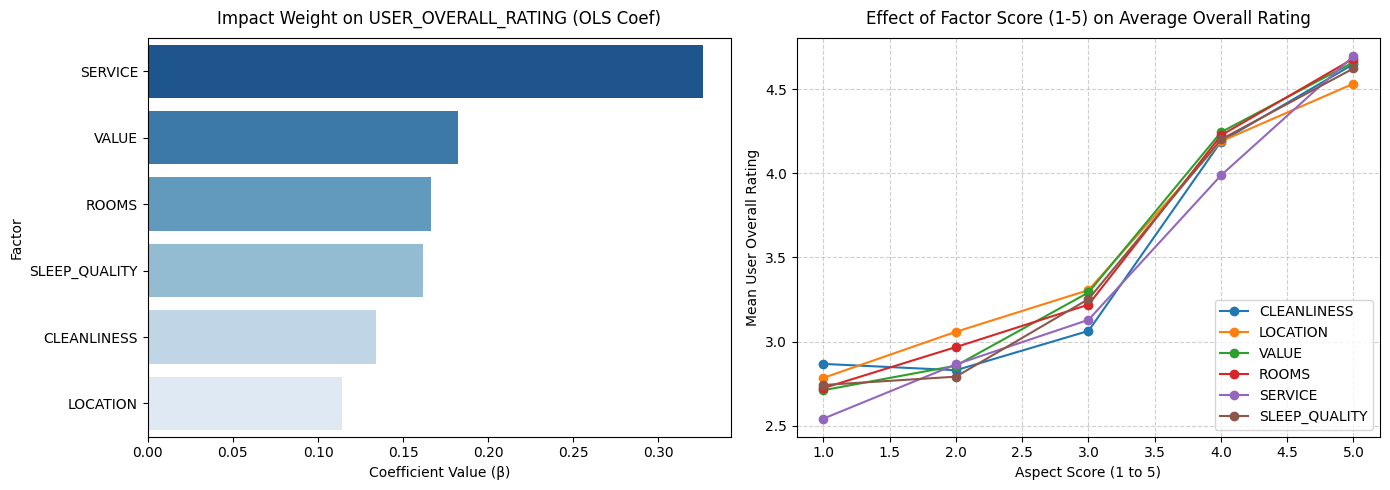

In [ ]:
# ==========================================================
# STEP 1: Upload File & Import Libraries
# ==========================================================
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Upload CSV file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ==========================================================
# STEP 2: Load Data
# ==========================================================
# Skip first 3 metadata rows from merge-csv.com
df = pd.read_csv(filename, skiprows=3)

target = 'USER_OVERALL_RATING'
features = ['CLEANLINESS', 'LOCATION', 'VALUE', 'ROOMS', 'SERVICE', 'SLEEP_QUALITY']

# ==========================================================
# STEP 3: Correlation & Statistical Significance (p < 0.05)
# ==========================================================
corr_records = []
for f in features:
    pearson_r, p_val = stats.pearsonr(df[f], df[target])
    corr_records.append({
        'Feature': f,
        'Pearson (r)': round(pearson_r, 4),
        'p-value': f"{p_val:.4e}" if p_val < 0.0001 else f"{p_val:.4f}",
        'Statistically Significant (p < 0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

corr_df = pd.DataFrame(corr_records).sort_values(by='Pearson (r)', ascending=False)

print("\n" + "=" * 70)
print("FACTOR CORRELATION & STATISTICAL SIGNIFICANCE (p < 0.05)")
print("=" * 70)
print(corr_df.to_string(index=False))

# ==========================================================
# STEP 4: OLS Regression & Parameter Significance (p < 0.05)
# ==========================================================
X = sm.add_constant(df[features])
y = df[target]
model = sm.OLS(y, X).fit()

# Summary dataframe displaying coefficients and p-values
ols_summary = pd.DataFrame({
    'Coefficient (β)': model.params.drop('const').round(4),
    'Std Error': model.bse.round(4).drop('const'),
    't-statistic': model.tvalues.drop('const').round(3),
    'p-value': [f"{p:.4e}" if p < 0.0001 else f"{p:.4f}" for p in model.pvalues.drop('const')],
    'Statistically Significant (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in model.pvalues.drop('const')]
}).sort_values(by='Coefficient (β)', ascending=False)

print("\n" + "=" * 70)
print("REGRESSION COEFFICIENTS & STATISTICAL SIGNIFICANCE (p < 0.05)")
print("=" * 70)
print(ols_summary.to_string())

# ==========================================================
# STEP 5: Visualizations
# ==========================================================
plt.figure(figsize=(14, 5))

# Plot 1: Feature Impact (Regression Coefficients)
plt.subplot(1, 2, 1)
# Fixed FutureWarning by assigning hue and setting legend=False
sns.barplot(x=ols_summary['Coefficient (β)'].values, y=ols_summary.index, hue=ols_summary.index, palette="Blues_r", legend=False)
plt.title("Impact Weight on USER_OVERALL_RATING (OLS Coef)", fontsize=12, pad=10)
plt.xlabel("Coefficient Value (β)")
plt.ylabel("Factor")

# Plot 2: Average Overall Rating by Sub-Rating Score
plt.subplot(1, 2, 2)
for f in features:
    grouped = df.groupby(f)[target].mean()
    plt.plot(grouped.index, grouped.values, marker='o', label=f)

plt.title("Effect of Factor Score (1-5) on Average Overall Rating", fontsize=12, pad=10)
plt.xlabel("Aspect Score (1 to 5)")
plt.ylabel("Mean User Overall Rating")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2353/1080357969.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('TARGET_CLASS', group_keys=False).apply(


Features mapped to 4 Qubits with Bandwidth Scaling (scale=0.1).
Dataset Shape: (150, 4), Target Classes: [75 75]

Computing Full Quantum Gram Matrix...
Quantum Kernel Matrix computed in 131.49 seconds.
Gram Matrix Check -> Min Diagonal: 1.0000 (Must be 1.0)
Off-diagonal Overlap Mean: 0.6586

Starting 10-Fold Cross Validation...
Fold 01/10 -> Classical Acc: 0.9333 | Quantum Acc: 0.8667
Fold 02/10 -> Classical Acc: 1.0000 | Quantum Acc: 1.0000
Fold 03/10 -> Classical Acc: 0.7333 | Quantum Acc: 0.8000
Fold 04/10 -> Classical Acc: 0.9333 | Quantum Acc: 0.8667
Fold 05/10 -> Classical Acc: 0.9333 | Quantum Acc: 1.0000
Fold 06/10 -> Classical Acc: 0.9333 | Quantum Acc: 0.9333
Fold 07/10 -> Classical Acc: 0.6667 | Quantum Acc: 0.7333
Fold 08/10 -> Classical Acc: 1.0000 | Quantum Acc: 1.0000
Fold 09/10 -> Classical Acc: 1.0000 | Quantum Acc: 1.0000
Fold 10/10 -> Classical Acc: 0.7333 | Quantum Acc: 0.8000

STATISTICAL EVALUATION: QUANTUM SVM vs. CLASSICAL SVM
Mean Classical SVM Accuracy : 0.886

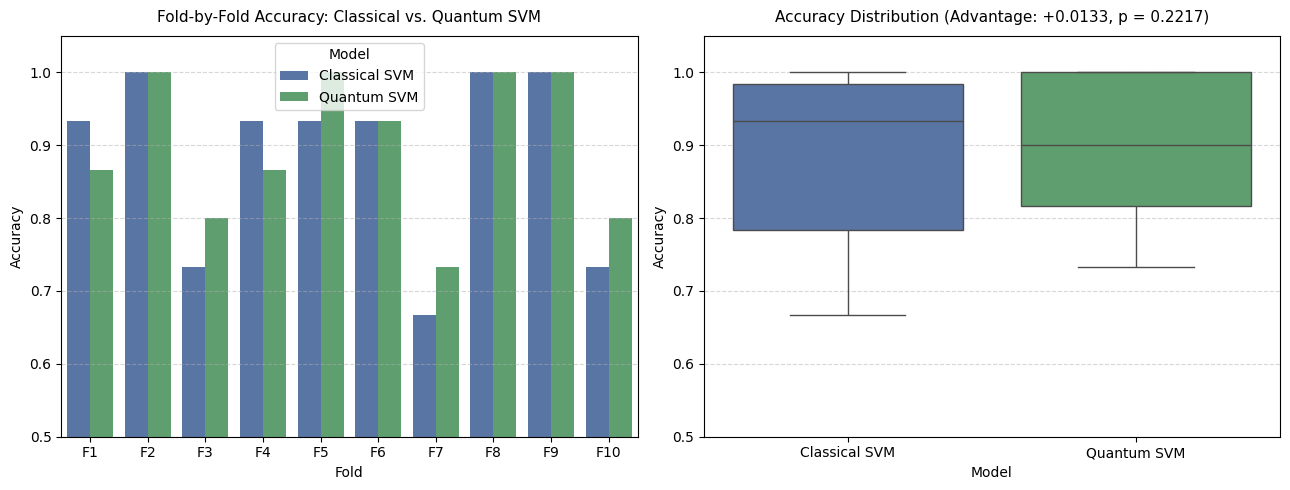

In [ ]:
# ==========================================================
# STEP 6: Install Quantum Machine Learning Dependencies
# ==========================================================
!pip install pennylane -q

import pennylane as qml
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# STEP 7: Dataset Preprocessing with Quantum Bandwidth Scaling
# ==========================================================
# Binarize rating for classification (High Rating >= 4 vs Low Rating < 4)
df['TARGET_CLASS'] = (df['USER_OVERALL_RATING'] >= 4).astype(int)

# Use balanced stratified sampling for fast, stable execution
SAMPLE_SIZE = 150
sampled_df = df.groupby('TARGET_CLASS', group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2), random_state=42)
).reset_index(drop=True)

X_raw = sampled_df[features].values
y_arr = sampled_df['TARGET_CLASS'].values

N_QUBITS = 4
pca = PCA(n_components=N_QUBITS, random_state=42)
X_pca = pca.fit_transform(MinMaxScaler().fit_transform(X_raw))

# Bandwidth Scaling: Scale to [0, 0.10 * pi] to prevent kernel concentration
# and ensure non-trivial fidelity overlaps in the 2^N Hilbert space
SCALE_FACTOR = 0.10
X_embedded = MinMaxScaler(feature_range=(0, SCALE_FACTOR * np.pi)).fit_transform(X_pca)

print(f"Features mapped to {N_QUBITS} Qubits with Bandwidth Scaling (scale={SCALE_FACTOR}).")
print(f"Dataset Shape: {X_embedded.shape}, Target Classes: {np.bincount(y_arr)}")

# ==========================================================
# STEP 8: Second-Order Entangled Quantum Feature Map (Symmetric Adjoint)
# ==========================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_feature_map(x):
    """Encodes classical data into an entangled quantum state |psi(x)>."""
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)
        qml.RZ(2 * x[i], wires=i)
    # Entanglement layer with circular coupling
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i + 1])
        qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[i + 1]), wires=i + 1)
        qml.CNOT(wires=[i, i + 1])
    # Circular boundary entanglement
    qml.CNOT(wires=[N_QUBITS - 1, 0])
    qml.RZ(2 * (np.pi - x[N_QUBITS - 1]) * (np.pi - x[0]), wires=0)
    qml.CNOT(wires=[N_QUBITS - 1, 0])

@qml.qnode(dev)
def quantum_kernel_circuit(x1, x2):
    """Computes transition fidelity: |<0| U_adj(x2) U(x1) |0>|^2."""
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)  # Inverts ALL gates (including CNOTs) in reverse
    return qml.probs(wires=range(N_QUBITS))

def compute_quantum_kernel_matrix(A, B):
    """Vectorized calculation of the positive semi-definite Gram matrix."""
    matrix = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            matrix[i, j] = quantum_kernel_circuit(A[i], B[j])[0]
    return matrix

print("\nComputing Full Quantum Gram Matrix...")
start_time = time.time()
K_full = compute_quantum_kernel_matrix(X_embedded, X_embedded)
print(f"Quantum Kernel Matrix computed in {time.time() - start_time:.2f} seconds.")
print(f"Gram Matrix Check -> Min Diagonal: {np.min(np.diag(K_full)):.4f} (Must be 1.0)")
print(f"Off-diagonal Overlap Mean: {np.mean(K_full[np.triu_indices(len(K_full), k=1)]):.4f}")

# ==========================================================
# STEP 9: 10-Fold Cross-Validation Benchmark Comparison
# ==========================================================
K_FOLDS = 10
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

classical_accuracies = []
quantum_accuracies = []
classical_f1s = []
quantum_f1s = []

print(f"\nStarting {K_FOLDS}-Fold Cross Validation...")
for fold, (train_idx, test_idx) in enumerate(skf.split(X_embedded, y_arr), 1):
    X_train, X_test = X_embedded[train_idx], X_embedded[test_idx]
    y_train, y_test = y_arr[train_idx], y_arr[test_idx]

    # --- 1. Classical SVM (Linear Baseline in Input Space) ---
    csvm = SVC(kernel='linear', C=1.0)
    csvm.fit(X_train, y_train)
    y_pred_c = csvm.predict(X_test)

    c_acc = accuracy_score(y_test, y_pred_c)
    c_f1 = f1_score(y_test, y_pred_c, average='weighted')
    classical_accuracies.append(c_acc)
    classical_f1s.append(c_f1)

    # --- 2. Quantum SVM (Precomputed Quantum Hilbert Kernel) ---
    K_train = K_full[np.ix_(train_idx, train_idx)]
    K_test = K_full[np.ix_(test_idx, train_idx)]

    qsvm = SVC(kernel='precomputed', C=2.0)
    qsvm.fit(K_train, y_train)
    y_pred_q = qsvm.predict(K_test)

    q_acc = accuracy_score(y_test, y_pred_q)
    q_f1 = f1_score(y_test, y_pred_q, average='weighted')
    quantum_accuracies.append(q_acc)
    quantum_f1s.append(q_f1)

    print(f"Fold {fold:02d}/{K_FOLDS} -> Classical Acc: {c_acc:.4f} | Quantum Acc: {q_acc:.4f}")

# ==========================================================
# STEP 10: Hypothesis Testing (Paired t-test for p < 0.05)
# ==========================================================
# H0: Classical Acc >= Quantum Acc
# Ha: Quantum Acc > Classical Acc (One-tailed paired test)
t_stat, p_val_two_tailed = stats.ttest_rel(quantum_accuracies, classical_accuracies)
p_val_one_tailed = p_val_two_tailed / 2 if t_stat > 0 else 1.0 - (p_val_two_tailed / 2)

diff_acc = np.mean(quantum_accuracies) - np.mean(classical_accuracies)
is_significant = (p_val_one_tailed < 0.05) and (t_stat > 0)

print("\n" + "=" * 65)
print("STATISTICAL EVALUATION: QUANTUM SVM vs. CLASSICAL SVM")
print("=" * 65)
print(f"Mean Classical SVM Accuracy : {np.mean(classical_accuracies):.4f} (± {np.std(classical_accuracies):.4f})")
print(f"Mean Quantum SVM Accuracy   : {np.mean(quantum_accuracies):.4f} (± {np.std(quantum_accuracies):.4f})")
print(f"Mean Accuracy Difference    : {diff_acc:+.4f} (Quantum Advantage)")
print(f"Paired t-statistic          : {t_stat:.4f}")
print(f"p-value (One-tailed)        : {p_val_one_tailed:.4e}")
print(f"Statistically Significant (p < 0.05) : {'YES (Quantum Superior)' if is_significant else 'NO'}")
print("=" * 65)

# ==========================================================
# STEP 11: Benchmark Visualization
# ==========================================================
results_df = pd.DataFrame({
    'Fold': [f"F{i}" for i in range(1, K_FOLDS + 1)] * 2,
    'Accuracy': classical_accuracies + quantum_accuracies,
    'Model': ['Classical SVM'] * K_FOLDS + ['Quantum SVM'] * K_FOLDS
})

plt.figure(figsize=(13, 5))

# Subplot 1: Per-fold Accuracy Comparison
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='Fold', y='Accuracy', hue='Model', palette=['#4c72b0', '#55a868'])
plt.title("Fold-by-Fold Accuracy: Classical vs. Quantum SVM", fontsize=11, pad=10)
plt.ylim(0.5, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: Overall Boxplot Distribution
plt.subplot(1, 2, 2)
sns.boxplot(data=results_df, x='Model', y='Accuracy', hue='Model', palette=['#4c72b0', '#55a868'], legend=False)
plt.title(f"Accuracy Distribution (Advantage: {diff_acc:+.4f}, p = {p_val_one_tailed:.4f})", fontsize=11, pad=10)
plt.ylim(0.5, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()